### Step Back

#### 一、核心动机
在RAG流程中，用户有时会提出非常具体或技术细节极强的问题
- 如果只针对具体的细节进行检索，可能会因为文档描述太细碎而无法获得完整的背景知识，或者因为关键词没对上而错过关键信息
- 由 Google 提出的 Step-Back Prompting 认为，我们应该针对原始问题，生成一个更抽象（Abstract）、更宏观（Generic）的问题
- 通过检索更基础的概念或原理（后退一步的问题），可以为解决那个具体的、困难的问题提供必要的背景支撑

#### 二、 工作原理
这一技术主要通过少样本提示（Few-shot Prompting）来实现，即给模型展示几个例子，教它如何把具体问题变抽象   

示例：  

- 具体问题：Janell 是在哪个国家出生的？
- 后退问题：Janell 的个人历史背景是什么？
- 具体问题：大模型代理中的任务分解（Task Decomposition）是什么？
- 后退问题：任务分解的基本流程是什么？

#### 三、实现方法
- 生成后退问题:LLM接收原始问题,生成一个更泛化的后退问题
- 双路检索:
  -  A:针对原始问题
  -  B:针对生成后的后退问题
-  上下文整合:将两路检索回来的文档全部放入最终的prompt模板
-  最终回答:LLM结合基础原理和具体细节,给出一个深度且准确的答案

In [1]:
# Indexing
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
print(blog_docs)


c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [2]:
#Split
from langchain_text_splitters import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=300, chunk_overlap=50)
splits = text_splitter.split_documents(blog_docs)  
print(splits)  # 打印分割后的 Document 对象列表

Created a chunk of size 492, which is longer than the specified 300
Created a chunk of size 341, which is longer than the specified 300
Created a chunk of size 336, which is longer than the specified 300
Created a chunk of size 2671, which is longer than the specified 300
Created a chunk of size 716, which is longer than the specified 300
Created a chunk of size 620, which is longer than the specified 300
Created a chunk of size 1373, which is longer than the specified 300
Created a chunk of size 738, which is longer than the specified 300
Created a chunk of size 1281, which is longer than the specified 300
Created a chunk of size 363, which is longer than the specified 300
Created a chunk of size 344, which is longer than the specified 300
Created a chunk of size 398, which is longer than the specified 300
Created a chunk of size 370, which is longer than the specified 300
Created a chunk of size 542, which is longer than the specified 300
Created a chunk of size 2352, which is longer

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Planning'), Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-0

In [3]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    persist_directory="./chroma_db"  # 向量库保存路径
)
vectorstore.persist()  # 持久化存储
retriever = vectorstore.as_retriever() 

C:\Users\23017\AppData\Local\Temp\ipykernel_19964\2382097115.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1292.53it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\23017\AppData\Local\Temp\ipykernel_19964\2382097115.py:15: LangChainDep

In [7]:
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate

examples = [
    {
        "input": "Could the members of The Police perform lawful arrests?",
        "output": "what can the members of The Police do?",
    },
    {
        "input": "Jan Sindel’s was born in what country?",
        "output": "what is Jan Sindel’s personal history?",
    },
]

# 使用 ChatPromptTemplate.from_messages 创建示例提示模板
example_prompt = ChatPromptTemplate.from_messages(
    [
        ("human", "{input}"),
        ("ai", "{output}"),
    ]
)

few_shot_prompt = FewShotChatMessagePromptTemplate(
    examples=examples,
    example_prompt=example_prompt,
)


prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an expert at world knowledge. Your task is to step back and paraphrase a question to a more generic step-back question, which is easier to answer. Here are a few examples:",
        ),
        few_shot_prompt,
        ("user", "{question}"),
    ]
)

print(prompt)

input_variables=['question'] input_types={} partial_variables={} messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an expert at world knowledge. Your task is to step back and paraphrase a question to a more generic step-back question, which is easier to answer. Here are a few examples:'), additional_kwargs={}), FewShotChatMessagePromptTemplate(examples=[{'input': 'Could the members of The Police perform lawful arrests?', 'output': 'what can the members of The Police do?'}, {'input': 'Jan Sindel’s was born in what country?', 'output': 'what is Jan Sindel’s personal history?'}], input_variables=[], input_types={}, partial_variables={}, example_prompt=ChatPromptTemplate(input_variables=['input', 'output'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs=

In [10]:
from langchain_community.chat_models.tongyi import ChatTongyi
import os 
from langchain_core.output_parsers import StrOutputParser
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY
CHUNK_SIZE = 1000  # 文本分块大小
CHUNK_OVERLAP = 200  # 分块重叠长度
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型
LLM_MODEL = "qwen-turbo"  # 通义千问免费模型
TEMPERATURE = 0.0  # 生成温度（0=稳定输出）
llm = ChatTongyi(
    model=LLM_MODEL,
    temperature=TEMPERATURE,
    dashscope_api_key=DASHSCOPE_API_KEY
)
generate_queries_step_back = prompt | llm | StrOutputParser()
question = "What is task decomposition for LLM agents? 用中文回答"
generate_queries_step_back.invoke({"question": question})

'LLM代理的任务分解是指将一个复杂的任务拆分成多个更小、更易处理的子任务，以便LLM能够逐步完成整个任务。这种分解通常包括识别任务的目标、确定完成任务所需的步骤、分配每个步骤的职责，并确保各步骤之间能够有效衔接。任务分解有助于提高LLM在处理复杂问题时的效率和准确性。'

In [11]:
from langchain_core.runnables import  RunnableLambda

response_prompt_template = """You are an expert of world knowledge. I am going to ask you a question. Your response should be comprehensive and not contradicted with the following context if they are relevant. Otherwise, ignore them if they are not relevant.

# {normal_context}
# {step_back_context}

# Original Question: {question}
# Answer:"""
response_prompt = ChatPromptTemplate.from_template(response_prompt_template)

chain = (
    {
        # Retrieve context using the normal question
        "normal_context": RunnableLambda(lambda x: x["question"]) | retriever,
        # Retrieve context using the step-back question
        "step_back_context": generate_queries_step_back | retriever,
        # Pass on the question
        "question": lambda x: x["question"],
    }
    | response_prompt
    | llm
    | StrOutputParser()
)

chain.invoke({"question": question})

'任务分解（task decomposition）是指将用户请求拆解为多个子任务的过程，这些子任务可以由大型语言模型（LLM）代理逐步完成。在LLM代理系统中，任务分解是第一个阶段，通常由LLM作为“大脑”来执行。在这个过程中，每个任务都有四个属性：任务类型、任务ID、依赖关系和参数。通过提供少量示例（few-shot examples），LLM被引导进行任务解析和规划。\n\n任务分解的目标是将复杂的用户请求分解为更小、更易处理的步骤，从而使得LLM能够有条不紊地执行任务，并在必要时使用工具（如ReAct格式）来完成具体操作。这种分解不仅提高了系统的效率，还增强了LLM在处理复杂任务时的准确性和可控性。'

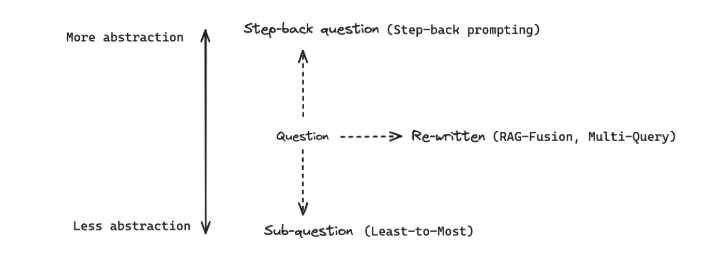